In [115]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram
import joblib

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram
import joblib

root = Path("/Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis/unsupervised_test_robust_scaler_v2")

labels_df = pd.read_csv(root / "kmeans_k3_labels.csv")
metrics_df = pd.read_csv(root / "kmeans_metrics.csv")
tsne_df = pd.read_csv(root / "tsne_2d.csv")
pca_df = pd.read_csv(root / "kmeans_k3_pca2.csv")
hier_labels_df = pd.read_csv(root / "hierarchical_labels_k3_sample.csv")
linkage_mat = np.loadtxt(root / "hierarchical_linkage_ward_sample.csv", delimiter=",", skiprows=1)
model = joblib.load(root / "kmeans_k3.pkl")


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
from scipy.cluster.hierarchy import dendrogram

from project_package.modeling import load_csv_dedup, EXCLUDE_ALWAYS, _unsup_pre_ordinal

def plot_clustering_validation(
    metrics_path: str,
    csv_path: str,
    linkage_path: str,
    id_cols: list = ["Booking ID", "Customer ID"],
    best_k: int = 3,
    cut_threshold: float = 25
):
    """
    Generate Elbow, Silhouette, and Hierarchical Dendrogram plots 
    for unsupervised clustering validation.

    Parameters
    ----------
    metrics_path : str
        Path to kmeans_metrics.csv file
    csv_path : str
        Path to original (scaled) data CSV
    linkage_path : str
        Path to hierarchical_linkage_ward_sample.csv file
    id_cols : list
        Columns to exclude from feature matrix
    best_k : int
        Number of clusters for silhouette plot
    cut_threshold : float
        Threshold line for dendrogram cut
    """

    # ========== 1. Load metrics ==========
    metrics = pd.read_csv(metrics_path)

    # ========== 2. Load data ==========
    df = load_csv_dedup(csv_path)
    drop_cols = set(EXCLUDE_ALWAYS) | set(id_cols)
    X_raw = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
    pre = _unsup_pre_ordinal(X_raw)
    X = pre.fit_transform(X_raw)

    # ========== 3. Load linkage matrix ==========
    Z = pd.read_csv(linkage_path).values

    # ========== 4. Fit KMeans for silhouette ==========
    km = KMeans(n_clusters=best_k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    sil_vals = silhouette_samples(X, labels)

    # ========== 5. Plot ==========
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ---- (a) Elbow plot ----
    axes[0].plot(metrics['k'], metrics['wcss'], marker='o', color='tab:blue')
    axes[0].set_xlabel('Number of clusters (k)')
    axes[0].set_ylabel('WCSS (distortion)')
    axes[0].set_title('Elbow Method for KMeans')
    axes[0].grid(True)

    # ---- (b) Silhouette plot ----
    y_lower = 10
    for i in range(best_k):
        ith_vals = sil_vals[labels == i]
        ith_vals.sort()
        size_cluster_i = ith_vals.shape[0]
        y_upper = y_lower + size_cluster_i
        color = plt.cm.tab10(float(i) / best_k)
        axes[1].fill_betweenx(np.arange(y_lower, y_upper),
                              0, ith_vals,
                              facecolor=color, edgecolor=color, alpha=0.7)
        axes[1].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    axes[1].axvline(x=sil_vals.mean(), color="red", linestyle="--", label="Avg silhouette")
    axes[1].set_xlabel("Silhouette coefficient")
    axes[1].set_ylabel("Cluster label")
    axes[1].set_title(f"Silhouette Plot (k={best_k})")
    axes[1].legend()

    # ---- (c) Dendrogram ----
    dendrogram(Z, truncate_mode='level', p=5, color_threshold=cut_threshold, ax=axes[2])
    axes[2].axhline(y=cut_threshold, c='red', lw=2, linestyle='--')
    axes[2].set_title("Hierarchical Clustering Dendrogram (truncated)")
    axes[2].set_xlabel("Samples")
    axes[2].set_ylabel("Distance")

    plt.tight_layout()
    plt.show()

    print(f"✅ Validation plots generated using k={best_k}")

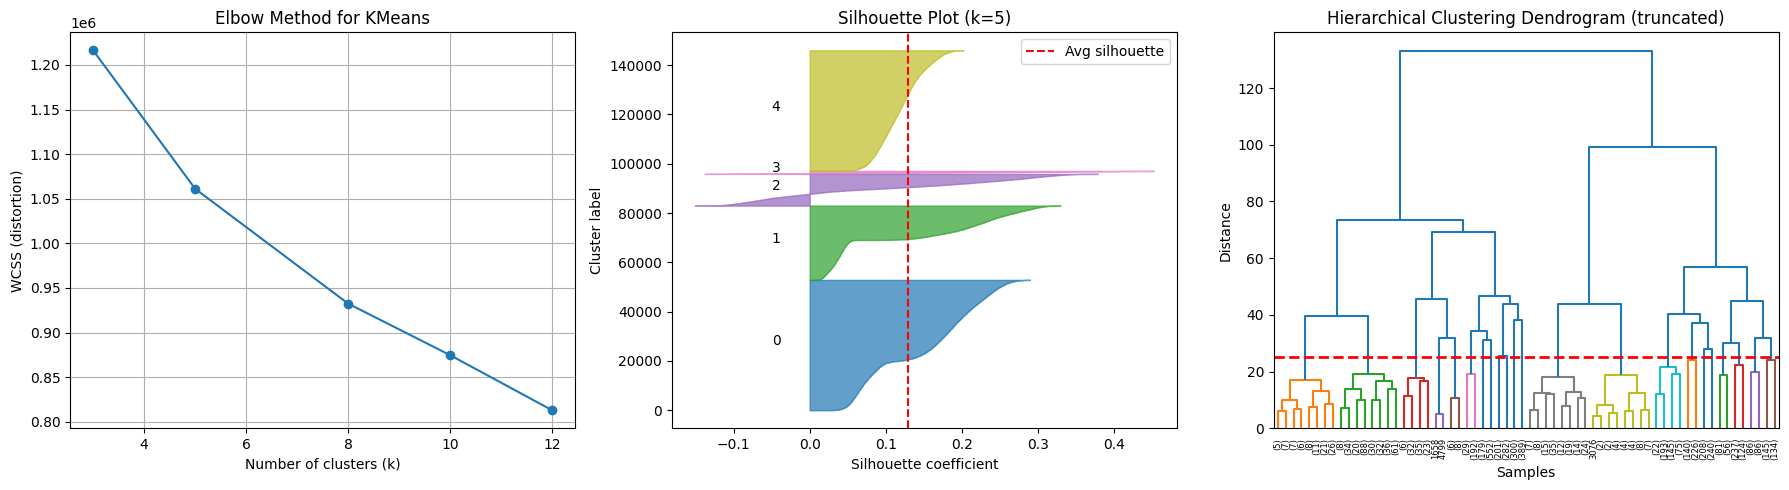

✅ Validation plots generated using k=5


In [3]:
plot_clustering_validation(
    metrics_path="unsupervised_test_robust_scaler_v2/kmeans_metrics.csv",
    csv_path="unsupervised_modelling_validation_scaled_v2.csv",
    linkage_path="unsupervised_test_robust_scaler_v2/hierarchical_linkage_ward_sample.csv",
    best_k=5,
    cut_threshold=25
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:453: UserWarning: Exited at iteration 217 with accuracies 
[1.47375420e-15 1.24242277e-05 1.53546113e-05 5.59966367e-06]
not reaching the requested tolerance 5.602836608886719e-06.
Use iteration 103 instead with accuracy 
4.333790451402207e-06.

  _, diffusion_map = lobpcg(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:453: UserWarning: Exited postprocessing with accuracies 
[1.49101321e-15 6.30256503e-06 4.19048378e-06 6.84211300e-06]
not reaching the requested tolerance 5.602836608886719e-06.
  _, diffusion_map = lobpcg(


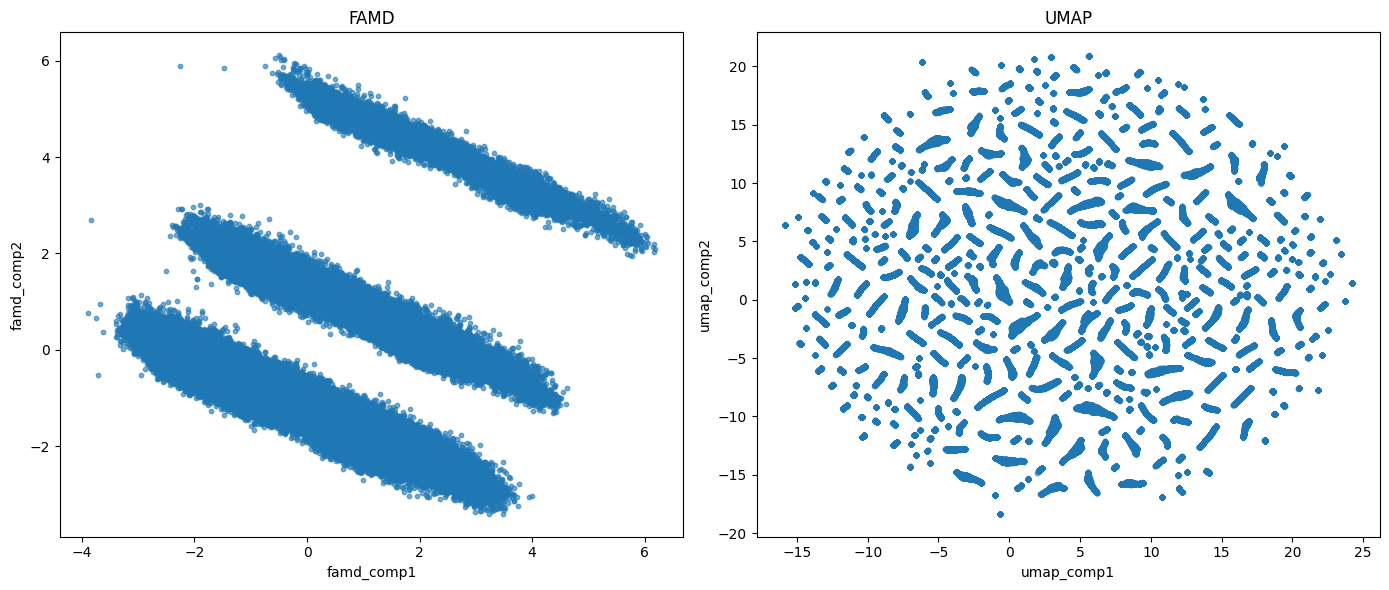

In [14]:
import pandas as pd
import prince
import umap
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("unsupervised_modelling_validation_v2.csv")
id_cols = ["Booking ID", "Customer ID"]
df_famd = df.drop(columns=[c for c in id_cols if c in df.columns])

# FAMD embedding
famd = prince.FAMD(n_components=20, n_iter=3, random_state=42)
X_famd = famd.fit_transform(df_famd)

# UMAP on top of FAMD
umap_model = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_famd)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# FAMD 2D projection (just take first 2 components)
plt.sca(axes[0])
plt.scatter(X_famd.iloc[:,0], X_famd.iloc[:,1], s=10, alpha=0.6)
plt.title("FAMD")
plt.xlabel("famd_comp1")
plt.ylabel("famd_comp2")

# UMAP projection
plt.sca(axes[1])
plt.scatter(X_umap[:,0], X_umap[:,1], s=10, alpha=0.6)
plt.title("UMAP")
plt.xlabel("umap_comp1")
plt.ylabel("umap_comp2")

plt.tight_layout()
plt.show()

#save FAMD output to csv
X_famd.to_csv("unsupervised_modelling_validation_famd20_v2.csv", index=False)

In [15]:
X_famd

component,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,4.242031,3.351178,1.321017,2.634358,1.218077,-1.496132,2.342518,-1.685059,0.365392,1.844433,1.322959,2.201776,1.364774,0.618299,1.237765,-1.520500,-0.571165,1.026151,-2.370083,3.140117
1,-0.063142,1.967463,1.432819,-1.154287,1.116760,1.750513,-1.191956,0.959174,-0.004239,-1.614902,0.436423,-1.320924,1.449955,-0.617455,1.675609,1.377407,0.661698,-0.363904,-0.576752,0.239917
2,0.663405,-1.509161,-0.742379,-1.509612,0.166355,-1.686279,0.783182,-0.447125,-0.740769,-1.021894,-1.979003,1.590047,-0.705040,0.430053,-1.513726,1.584056,-0.752482,0.696933,-0.823041,-2.713971
3,-2.008275,-0.346392,-0.421349,0.451736,0.639492,-1.653551,0.300349,0.264277,0.023165,-1.313391,2.171525,-0.823066,-0.826989,0.852195,-0.744260,-1.453952,0.713558,0.076669,1.681323,-0.399521
4,-2.065088,-0.452283,-0.006825,-1.655325,4.171806,-1.125459,0.175535,-0.030825,-1.218316,0.338215,-0.957825,0.565419,-3.080679,-0.592371,-0.568788,-0.138054,1.282788,0.820409,-1.228610,1.252246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145977,-0.102016,-1.182818,-1.033906,0.588558,-2.845150,0.248040,2.073367,-0.249025,0.637812,0.388291,-2.104500,-0.611179,-1.848845,-0.727458,0.406266,0.628453,-0.338531,-1.458439,0.188895,1.654528
145978,-2.241156,-0.482627,0.101257,0.436996,-1.937932,0.336760,-1.133240,-0.127770,-0.335011,0.541014,0.516022,0.407313,-1.056920,-0.614747,1.066395,-0.683115,-2.341416,-0.220279,-0.754225,-1.921728
145979,-0.782799,-0.922411,-2.613084,0.983045,-1.503568,-1.335489,-0.833593,-0.566899,1.484203,-0.246430,-0.005264,-0.899499,-0.430236,-0.852942,1.353532,-0.063078,2.856036,-0.062421,-0.215343,-0.852772
145980,1.054669,-1.813692,1.456059,1.088469,0.564119,2.827119,-2.048722,-0.467422,0.405788,-1.013205,0.160007,0.147320,-0.652055,1.722648,-0.560034,-0.696036,0.670497,-0.978408,-0.755307,-0.250415


In [ ]:
import pandas as pd

# Load original IDs (from your original dataset)
df_original = pd.read_csv("unsupervised_modelling_validation_v2.csv")
id_cols = ["Booking ID", "Customer ID"]
df_ids = df_original[id_cols]

# Load cluster labels (from KMeans output)
labels = pd.read_csv("unsupervised_test_famd20/kmeans_k12_labels.csv")

# Merge IDs with labels by row index
# (since both should be in the same order as the original dataset)
df_clusters = pd.concat([df_ids.reset_index(drop=True), labels], axis=1)

df_clusters.to_csv("unsupervised_test_famd20/kmeans_k12_labels_with_ids.csv", index=False)
print(df_clusters.head())

# Merge by index (or Booking ID if available)
df_final = pd.concat([df_original.reset_index(drop=True), df_clusters['cluster']], axis=1)

# Check result
print(df_final.head())



     Booking ID   Customer ID  cluster
0  "CNR5884300"  "CID1982111"        6
1  "CNR1326809"  "CID4604802"        6
2  "CNR8494506"  "CID9202816"        9
3  "CNR8906825"  "CID2610914"        2
4  "CNR1950162"  "CID9933542"        8
     Booking ID   Customer ID   Vehicle Type  hour  temperature_2m_pickup  \
0  "CNR5884300"  "CID1982111"          eBike    12                   31.8   
1  "CNR1326809"  "CID4604802"       Go Sedan    18                   19.1   
2  "CNR8494506"  "CID9202816"           Auto     8                   30.8   
3  "CNR8906825"  "CID2610914"  Premier Sedan    17                   24.8   
4  "CNR1950162"  "CID9933542"           Bike    22                   24.6   

   relative_humidity_2m_pickup  dew_point_2m_pickup  precipitation_pickup  \
0                         24.0                  8.9                   0.0   
1                         51.0                  8.6                   0.0   
2                         75.0                 25.8                   0.

In [20]:
df_final.columns

Index(['Booking ID', 'Customer ID', 'Vehicle Type', 'hour',
       'temperature_2m_pickup', 'relative_humidity_2m_pickup',
       'dew_point_2m_pickup', 'precipitation_pickup', 'snowfall_pickup',
       'wind_speed_10m_pickup', 'AvgVTAT_missing_flag',
       'DriverRatings_missing_flag', 'Avg VTAT_fill', 'Avg CTAT_fill',
       'Booking Value_fill', 'Ride Distance_fill', 'Driver Ratings_fill',
       'Customer Rating_fill', 'cluster'],
      dtype='object')

In [22]:
num_cols = [
    'hour', 'temperature_2m_pickup', 'relative_humidity_2m_pickup', 'dew_point_2m_pickup',
    'precipitation_pickup', 'snowfall_pickup', 'wind_speed_10m_pickup',
    'Avg VTAT_fill', 'Avg CTAT_fill', 'Booking Value_fill',
    'Ride Distance_fill', 'Driver Ratings_fill', 'Customer Rating_fill'
]

cluster_num_summary = df_final.groupby('cluster')[num_cols].agg(['mean', 'median', 'std']).round(2)
cluster_num_summary

hour              temperature_2m_pickup               \
          mean median   std                  mean median   std   
cluster                                                          
0        15.45   19.0  7.18                 22.01   23.9  7.13   
1        11.00   11.0  0.00                 29.42   29.9  6.91   
2        15.61   17.0  4.02                 23.52   25.1  7.02   
3        15.54   16.0  0.50                 24.07   25.6  7.00   
4        23.00   23.0  0.00                 20.57   22.5  7.10   
5         2.00    3.0  1.00                 22.34   24.7  7.67   
6        14.11   14.0  3.99                 25.30   26.3  7.53   
7        20.00   20.0  0.00                 21.60   23.5  7.06   
8        17.30   21.0  6.51                 23.67   24.9  7.97   
9         7.99    8.0  1.37                 29.81   30.5  6.96   
10        9.95   10.0  0.58                 30.20   30.6  6.81   
11       13.00   13.0  0.00                 26.49   27.4  7.24   

        relative_humidity_2m_pickup               dew_point_2m_pickup  ...  \
                               mean median    std                mean  ...   
cluster                                                                ...   
0                             73.61   82.0  23.09               15.97  ...   
1                             49.37   52.0  22.80               15.42  ...   
2                             69.19   77.0  23.64               16.23  ...   
3                             67.00   75.0  24.45               16.03  ...   
4                             77.74   87.0  22.39               15.63  ...   
5                             75.25   82.0  20.53               16.90  ...   
6                             63.11   68.0  24.83               16.00  ...   
7                             74.76   84.0  22.99               15.87  ...   
8                             68.17   73.0  25.31               15.88  ...   
9                             48.45   49.0  21.78               15.70  ...   
10                            46.66   47.0  22.36               15.22  ...   
11                            59.76   66.0  24.45               16.06  ...   

        Booking Value_fill Ride Distance_fill                \
                       std               mean median    std   
cluster                                                       
0                   322.90              24.62  24.62  11.52   
1                   325.97              24.30  24.62  11.65   
2                   325.16              24.74  24.62  11.58   
3                   326.11              24.74  24.62  11.57   
4                   329.68              24.94  24.62  11.74   
5                   336.91              24.95  24.62  11.35   
6                   324.93              24.63  24.62  11.42   
7                   315.56              24.58  24.62  11.57   
8                   326.41              24.55  24.62  11.50   
9                   332.98              24.72  24.62  11.52   
10                  326.24              24.54  24.62  11.65   
11                  324.88              24.61  24.62  11.54   

        Driver Ratings_fill              Customer Rating_fill               
                       mean median   std                 mean median   std  
cluster                                                                     
0                      4.23   4.23  0.34                 4.40    4.4  0.35  
1                      4.23   4.23  0.35                 4.41    4.4  0.34  
2                      4.23   4.23  0.34                 4.40    4.4  0.34  
3                      4.23   4.23  0.34                 4.40    4.4  0.34  
4                      4.23   4.23  0.34                 4.41    4.4  0.34  
5                      4.22   4.23  0.36                 4.40    4.4  0.34  
6                      4.23   4.23  0.34                 4.40    4.4  0.34  
7                      4.24   4.23  0.34                 4.40    4.4  0.35  
8                      4.23   4.23  0.34               

In [23]:
vehicle_distribution = (
    df_final.groupby(['cluster', 'Vehicle Type'])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to percentages
vehicle_distribution_pct = vehicle_distribution.div(vehicle_distribution.sum(axis=1), axis=0) * 100
vehicle_distribution_pct.round(2)

Vehicle Type,Auto,Bike,Go Mini,Go Sedan,Premier Sedan,Uber XL,eBike
cluster,,,,,,,
0,24.98,14.82,19.95,18.06,12.14,2.95,7.10
1,25.06,15.00,20.55,17.71,11.95,3.20,6.53
2,25.59,15.31,19.44,17.97,11.57,2.90,7.22
3,25.16,14.82,20.15,17.39,12.39,3.06,7.04
4,25.17,15.53,20.31,17.49,11.86,3.22,6.41
5,23.49,15.20,19.44,19.06,12.23,2.66,7.92
6,25.14,15.12,19.91,18.32,12.16,2.39,6.96
7,24.86,15.01,19.70,17.89,12.03,3.15,7.36
8,24.98,15.14,19.57,18.64,11.91,2.61,7.15


In [25]:
hour_dist = df_final.groupby(['cluster', 'hour']).size().unstack(fill_value=0)
hour_dist_pct = hour_dist.div(hour_dist.sum(axis=1), axis=0) * 100
hour_dist_pct.round(2)

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
cluster,,,,,,,,,,,,,,,,,,,,,
0,9.97,0.00,9.72,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.0,0.00,80.31,0.0,0.00,0.00,0.0
1,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00,0.0
2,0.00,0.00,0.00,0.00,10.7,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,89.3,0.00,0.00,0.0,0.00,0.00,0.0
3,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,45.97,54.03,0.0,0.00,0.00,0.0,0.00,0.00,0.0
4,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00,100.0
5,0.00,49.76,0.00,50.24,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00,0.0
6,0.00,0.00,0.00,0.00,0.0,0.00,13.28,0.00,0.00,0.00,...,23.06,0.00,0.00,0.0,40.77,0.00,0.0,0.00,0.00,0.0
7,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.0,0.00,0.00,100.0,0.00,0.00,0.0
8,0.00,0.00,0.00,0.00,0.0,0.00,0.00,28.47,0.00,0.00,...,0.00,0.00,0.00,0.0,0.00,0.00,0.0,42.85,28.68,0.0


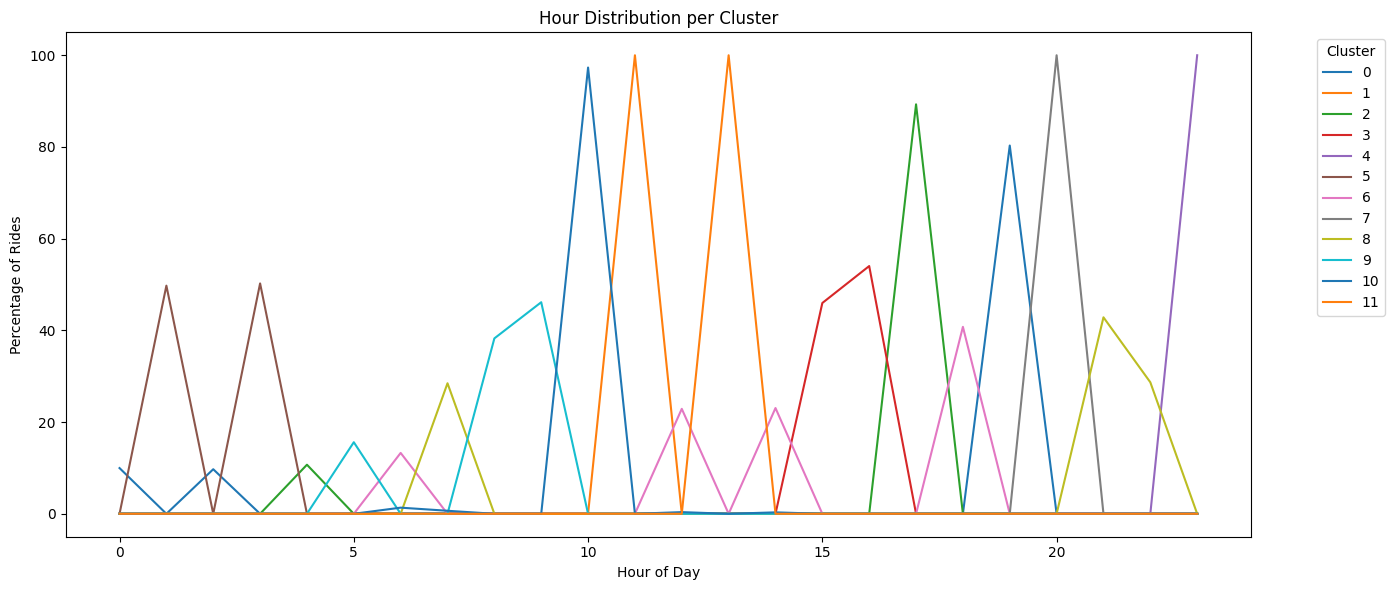

In [26]:
import matplotlib.pyplot as plt

hour_dist_pct.T.plot(figsize=(14,6))
plt.title("Hour Distribution per Cluster")
plt.xlabel("Hour of Day")
plt.ylabel("Percentage of Rides")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [28]:
weather_cols = [
    'temperature_2m_pickup', 'relative_humidity_2m_pickup',
    'precipitation_pickup', 'snowfall_pickup', 'wind_speed_10m_pickup'
]

weather_summary = df_final.groupby('cluster')[weather_cols].mean().round(2)
weather_summary

,temperature_2m_pickup,relative_humidity_2m_pickup,precipitation_pickup,snowfall_pickup,wind_speed_10m_pickup
cluster,,,,,
0,22.01,73.61,0.13,0.0,8.27
1,29.42,49.37,0.15,0.0,10.83
2,23.52,69.19,0.13,0.0,8.58
3,24.07,67.00,0.15,0.0,8.67
4,20.57,77.74,0.15,0.0,7.99
5,22.34,75.25,0.16,0.0,8.59
6,25.30,63.11,0.15,0.0,9.06
7,21.60,74.76,0.16,0.0,8.14
8,23.67,68.17,0.15,0.0,8.71


In [29]:
missing_cols = ['AvgVTAT_missing_flag', 'DriverRatings_missing_flag']
missing_summary = df_final.groupby('cluster')[missing_cols].mean().round(3)
missing_summary

,AvgVTAT_missing_flag,DriverRatings_missing_flag
cluster,,
0,0.071,0.385
1,0.072,0.375
2,0.068,0.380
3,0.070,0.384
4,0.064,0.377
5,0.075,0.384
6,0.072,0.385
7,0.070,0.378
8,0.070,0.381


Validation

In [32]:
kmeans_metrics = pd.read_csv('unsupervised_test_famd20/kmeans_metrics.csv')
kmeans_metrics

,k,silhouette,dbi,ch,wcss,bss,w_over_b
0,3,0.087496,3.392252,7818.008825,5491392.00,588193.50,9.336030
1,5,0.131147,2.611125,8115.291988,4973598.50,1105987.00,4.496977
2,8,0.196941,2.094370,8931.928313,4256459.00,1823126.50,2.334703
3,10,0.218533,1.866653,9240.902679,3872952.50,2206633.00,1.755141
4,12,0.265105,1.612555,10156.860897,3443743.75,2635841.75,1.306506


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from tqdm import tqdm

def clustering_validation_plots(
    X, 
    max_k=15, 
    best_k=None, 
    dendro_sample=3000, 
    cut_threshold=25,
    random_state=42
):
    """
    Generate Elbow, Silhouette and Hierarchical Clustering Dendrogram plots.

    Parameters
    ----------
    X : array or DataFrame
        Feature matrix.
    max_k : int
        Maximum number of clusters for elbow and silhouette.
    best_k : int or None
        Best k for silhouette plot. If None, will use the k with highest silhouette score.
    dendro_sample : int
        Sample size for dendrogram.
    cut_threshold : float
        Cut height line in dendrogram.
    random_state : int
        Random seed.
    """

    inertia_scores = []
    sil_scores = []

    # ============ 1. Elbow + Silhouette scores ============
    for k in tqdm(range(2, max_k + 1)):
        km = KMeans(n_clusters=k, n_init=10, random_state=random_state)
        labels = km.fit_predict(X)
        inertia_scores.append(km.inertia_)
        sil = silhouette_score(X, labels)
        sil_scores.append(sil)

    k_range = range(2, max_k + 1)
    if best_k is None:
        best_k = k_range[np.argmax(sil_scores)]

    # ============ 2. Silhouette Plot ============
    km_best = KMeans(n_clusters=best_k, n_init=10, random_state=random_state)
    labels_best = km_best.fit_predict(X)
    sil_values = silhouette_samples(X, labels_best)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ---- Elbow plot ----
    axes[0].plot(k_range, inertia_scores, marker='o')
    axes[0].set_title('Elbow Method for KMeans')
    axes[0].set_xlabel('Number of clusters (k)')
    axes[0].set_ylabel('WCSS (distortion)')
    axes[0].axvline(x=best_k, color='black', linestyle='--', label=f'elbow at k={best_k}')
    axes[0].legend()
    axes[0].grid(True)

    # ---- Silhouette plot ----
    y_lower = 10
    for i in range(best_k):
        ith_sil = sil_values[labels_best == i]
        ith_sil.sort()
        size_cluster_i = ith_sil.shape[0]
        y_upper = y_lower + size_cluster_i
        color = plt.cm.tab10(float(i) / best_k)
        axes[1].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                              facecolor=color, edgecolor=color, alpha=0.7)
        axes[1].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    axes[1].axvline(x=np.mean(sil_values), color="red", linestyle="--", label="Avg silhouette")
    axes[1].set_xlabel("Silhouette coefficient")
    axes[1].set_ylabel("Cluster label")
    axes[1].set_title(f"Silhouette Plot (k={best_k})")
    axes[1].legend()

    # ============ 3. Hierarchical Clustering ============
    # take a subsample for efficiency
    if X.shape[0] > dendro_sample:
        X_sub = X[np.random.choice(X.shape[0], dendro_sample, replace=False)]
    else:
        X_sub = X

    Z = linkage(X_sub, method='ward')
    dendrogram(Z, truncate_mode='level', p=5, color_threshold=cut_threshold, ax=axes[2])
    axes[2].axhline(y=cut_threshold, c='red', lw=2, linestyle='--')
    axes[2].set_title("Hierarchical Clustering Dendrogram (truncated)")
    axes[2].set_xlabel("Samples")
    axes[2].set_ylabel("Distance")

    plt.tight_layout()
    plt.show()

    print(f"[INFO] Best k for silhouette: {best_k}, silhouette = {max(sil_scores):.4f}")

100%|██████████| 14/14 [24:48<00:00, 106.31s/it]


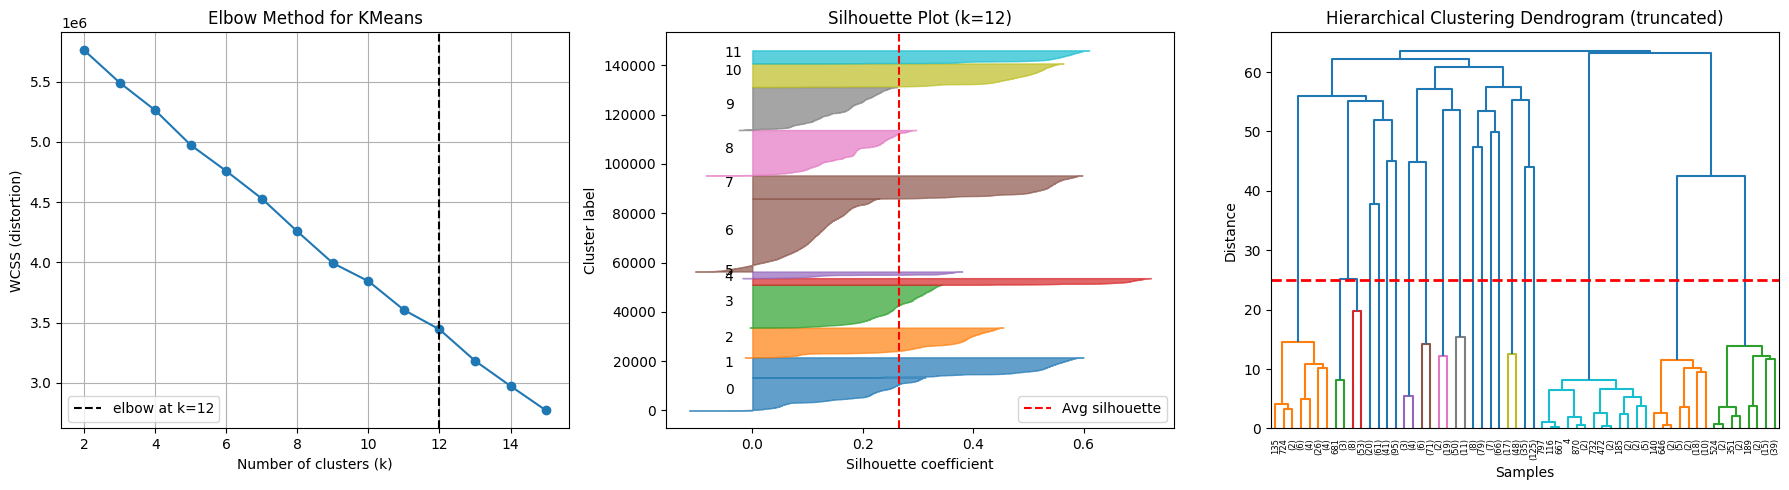

[INFO] Best k for silhouette: 12, silhouette = 0.3429


In [36]:
# Example with FAMD-transformed dataset
# with best k = 12
X_famd = X_famd.to_numpy()
clustering_validation_plots(
    X_famd,
    max_k=15,
    best_k=12,
    dendro_sample=1000,
    cut_threshold=25
)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


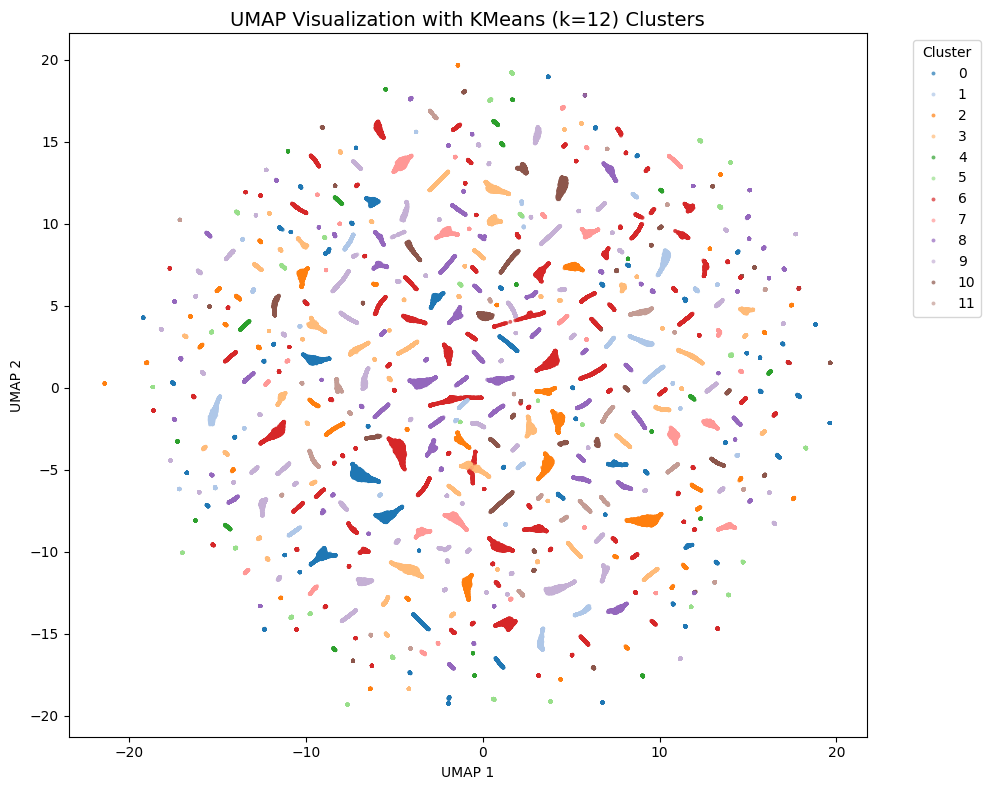

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap  # make sure to `pip install umap-learn` if not installed

# === Load or reuse your FAMD-transformed dataset ===
X_famd = pd.read_csv("unsupervised_modelling_validation_famd20_v2.csv")

# === Load KMeans labels ===
labels_path = "/Users/makabaka/Documents/GitHub/MADS-MS2-Uber-Analysis/unsupervised_test_famd20/kmeans_k12_labels.csv"
labels_df = pd.read_csv(labels_path)
labels = labels_df['cluster'].values

# === Run UMAP ===
reducer = umap.UMAP(
    n_neighbors=30,        # typical range: 15–50
    min_dist=0.1,          # controls tightness of clusters
    n_components=2,        # 2D projection
    metric='manhattan',
    random_state=42
)
X_umap = reducer.fit_transform(X_famd)

# === Convert to DataFrame for plotting ===
umap_df = pd.DataFrame(X_umap, columns=['umap1', 'umap2'])
umap_df['cluster'] = labels

# === Plot ===
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x='umap1',
    y='umap2',
    hue='cluster',
    palette='tab20',
    s=8,
    alpha=0.7,
    linewidth=0
)
plt.title('UMAP Visualization with KMeans (k=12) Clusters', fontsize=14)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
columns = [#'pick_region',
#'date',
'hour',
'temperature_2m_pickup',
'relative_humidity_2m_pickup',
'dew_point_2m_pickup',
'apparent_temperature_pickup',
'precipitation_pickup',
'rain_pickup',
'snowfall_pickup',
'wind_speed_10m_pickup',
'AvgVTAT_missing_flag',
'AvgCTAT_missing_flag',
'BookingValue_missing_flag',
'RideDistance_missing_flag',
'DriverRatings_missing_flag',
'CustomerRating_missing_flag',
'Avg VTAT_fill',
'Avg CTAT_fill',
'Booking Value_fill',
'Ride Distance_fill',
'Driver Ratings_fill',
'Customer Rating_fill']

In [30]:
df_num = df_concat[columns]

In [31]:
corr_matrix = df_num.corr()

In [35]:
corr_matrix

,hour,temperature_2m_pickup,relative_humidity_2m_pickup,dew_point_2m_pickup,apparent_temperature_pickup,precipitation_pickup,rain_pickup,snowfall_pickup,wind_speed_10m_pickup,AvgVTAT_missing_flag,...,BookingValue_missing_flag,RideDistance_missing_flag,DriverRatings_missing_flag,CustomerRating_missing_flag,Avg VTAT_fill,Avg CTAT_fill,Booking Value_fill,Ride Distance_fill,Driver Ratings_fill,Customer Rating_fill
hour,1.000000,-0.310481,0.294532,-0.007042,-0.266133,0.001745,0.001689,0.002041,-0.149585,-3.003129e-03,...,0.000081,0.000081,0.001828,0.001828,-0.004553,-0.000890,-0.001565,-2.117270e-03,0.000405,-0.001869
temperature_2m_pickup,-0.310481,1.000000,-0.503211,0.350569,0.943630,0.009376,0.010266,-0.032361,0.325637,-4.095031e-03,...,-0.019987,-0.019987,-0.017098,-0.017098,0.000275,-0.002520,-0.003234,-1.171812e-03,-0.005255,0.001767
relative_humidity_2m_pickup,0.294532,-0.503211,1.000000,0.590176,-0.214822,0.148343,0.148183,0.008731,-0.279682,-2.950219e-02,...,-0.074089,-0.074089,-0.064351,-0.064351,-0.009991,-0.004605,-0.004163,2.469296e-03,0.000542,0.000564
dew_point_2m_pickup,-0.007042,0.350569,0.590176,1.000000,0.625174,0.145893,0.146591,-0.022717,-0.038135,-3.894817e-02,...,-0.103544,-0.103544,-0.090008,-0.090008,-0.010473,-0.007368,-0.006394,2.018591e-03,-0.004007,0.002423
apparent_temperature_pickup,-0.266133,0.943630,-0.214822,0.625174,1.000000,0.054702,0.055607,-0.032050,0.187292,-1.524304e-02,...,-0.048566,-0.048566,-0.041957,-0.041957,-0.003106,-0.004608,-0.004917,-3.914189e-04,-0.005770,0.002414
precipitation_pickup,0.001745,0.009376,0.148343,0.145893,0.054702,1.000000,0.999625,0.033091,0.057386,-5.923062e-03,...,-0.010096,-0.010096,-0.007617,-0.007617,-0.004314,0.001009,-0.004964,-4.635475e-03,-0.000465,0.002036
rain_pickup,0.001689,0.010266,0.148183,0.146591,0.055607,0.999625,1.000000,0.005718,0.057677,-6.053838e-03,...,-0.010136,-0.010136,-0.007694,-0.007694,-0.004411,0.000994,-0.005024,-4.611621e-03,-0.000426,0.002032
snowfall_pickup,0.002041,-0.032361,0.008731,-0.022717,-0.032050,0.033091,0.005718,1.000000,-0.009507,4.651871e-03,...,0.001325,0.001325,0.002689,0.002689,0.003469,0.000574,0.002104,-9.606501e-04,-0.001427,0.000178
wind_speed_10m_pickup,-0.149585,0.325637,-0.279682,-0.038135,0.187292,0.057386,0.057677,-0.009507,1.000000,-7.770995e-03,...,-0.019699,-0.019699,-0.017908,-0.017908,0.000067,0.000706,-0.001354,-2.132660e-03,-0.000384,-0.000290
AvgVTAT_missing_flag,-0.003003,-0.004095,-0.029502,-0.038948,-0.015243,-0.005923,-0.006054,0.004652,-0.007771,1.000000e+00,...,0.399224,0.399224,0.349985,0.349985,-0.000049,-0.000044,-0.000009,2.418209e-07,0.000035,0.000012


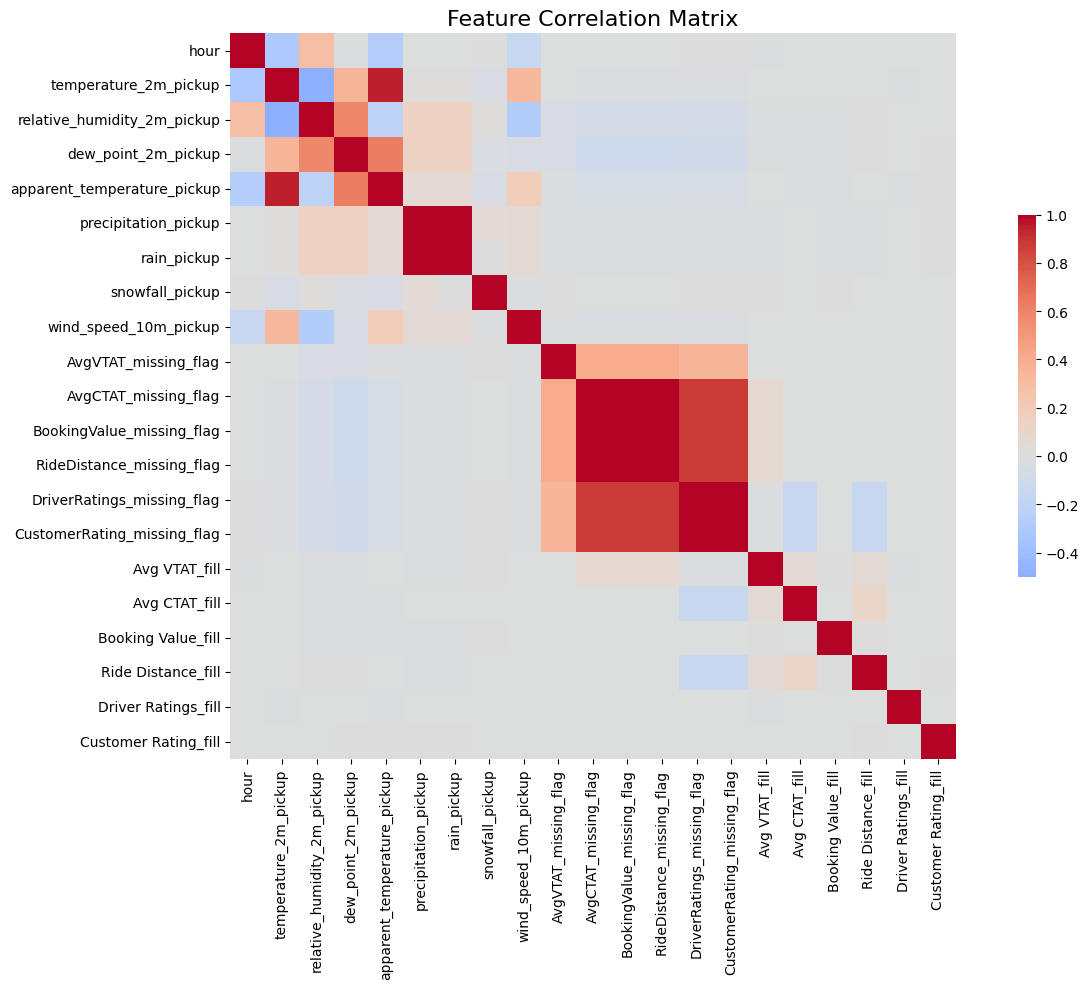

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={'shrink': 0.5}
)
plt.title("Feature Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

In [94]:
cols_to_keep = [
    'Booking ID', 'Customer ID',#join key
    "Vehicle Type",
    "hour",
    "temperature_2m_pickup",        # keep this instead of apparent_temperature_pickup
    "relative_humidity_2m_pickup",
    "dew_point_2m_pickup",
    # "apparent_temperature_pickup"  # dropped because strongly correlated with temperature
    "precipitation_pickup",         # keep this instead of rain_pickup
    # "rain_pickup",                # dropped (duplicate)
    "snowfall_pickup",
    "wind_speed_10m_pickup",
    
    "AvgVTAT_missing_flag",         # keep one representative of missing flag set
    # "AvgCTAT_missing_flag",       # dropped (duplicate with BookingValue_missing_flag)
    # "BookingValue_missing_flag",  # dropped (duplicate with AvgCTAT_missing_flag)
    # "RideDistance_missing_flag",  # dropped (duplicate with BookingValue_missing_flag)
    "DriverRatings_missing_flag",   # keep one
    # "CustomerRating_missing_flag", # dropped (duplicate)
    
    "Avg VTAT_fill",
    "Avg CTAT_fill",
    "Booking Value_fill",
    "Ride Distance_fill",
    "Driver Ratings_fill",
    "Customer Rating_fill"
]

In [95]:
df_final = df_concat[cols_to_keep]

In [96]:
df_final.to_csv("datasets/raw/merged/unsupervised_modelling_validation_v2.csv", index=False)

In [97]:
df_final

,Booking ID,Customer ID,Vehicle Type,hour,temperature_2m_pickup,relative_humidity_2m_pickup,dew_point_2m_pickup,precipitation_pickup,snowfall_pickup,wind_speed_10m_pickup,AvgVTAT_missing_flag,DriverRatings_missing_flag,Avg VTAT_fill,Avg CTAT_fill,Booking Value_fill,Ride Distance_fill,Driver Ratings_fill,Customer Rating_fill
0,"""CNR5884300""","""CID1982111""",eBike,12,31.8,24.0,8.9,0.0,0.0,16.6,1,1,8.489832,29.148323,503.256008,24.991943,4.224941,4.404470
1,"""CNR1326809""","""CID4604802""",Go Sedan,18,19.1,51.0,8.6,0.0,0.0,7.3,0,1,4.900000,14.000000,237.000000,5.730000,4.232220,4.408785
2,"""CNR8494506""","""CID9202816""",Auto,8,30.8,75.0,25.8,0.2,0.0,7.6,0,0,13.400000,25.800000,627.000000,13.580000,4.900000,4.900000
3,"""CNR8906825""","""CID2610914""",Premier Sedan,17,24.8,96.0,24.1,0.0,0.0,4.0,0,0,13.100000,28.500000,416.000000,34.020000,4.600000,5.000000
4,"""CNR1950162""","""CID9933542""",Bike,22,24.6,93.0,23.4,0.0,0.0,10.9,0,0,5.300000,19.600000,737.000000,48.210000,4.100000,4.300000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145977,"""CNR9572383""","""CID2952237""",Go Mini,16,30.7,56.0,21.0,0.0,0.0,19.6,0,0,8.200000,30.600000,388.000000,10.510000,4.300000,4.900000
145978,"""CNR6500631""","""CID4337371""",Go Mini,19,22.0,93.0,20.8,0.0,0.0,5.3,0,0,10.200000,44.400000,475.000000,40.080000,3.700000,4.100000
145979,"""CNR2468611""","""CID2325623""",Go Mini,15,25.6,70.0,19.8,0.0,0.0,12.5,0,0,5.100000,30.800000,1093.000000,21.310000,4.800000,5.000000
145980,"""CNR6358306""","""CID9925486""",Go Sedan,10,26.0,72.0,20.6,0.0,0.0,14.9,0,0,2.700000,23.400000,852.000000,15.930000,3.900000,4.400000


In [65]:
metrics_df

,k,silhouette,dbi,ch,wcss,bss,w_over_b
0,3,0.560358,0.577702,189772.436160,4.349404e+09,1.130760e+10,0.384644
1,5,0.631753,0.486413,361711.332609,1.434918e+09,1.422209e+10,0.100894
2,8,0.566913,0.558317,463419.323486,6.742131e+08,1.498279e+10,0.044999
3,10,0.517066,0.615879,509705.020260,4.828525e+08,1.517415e+10,0.031821


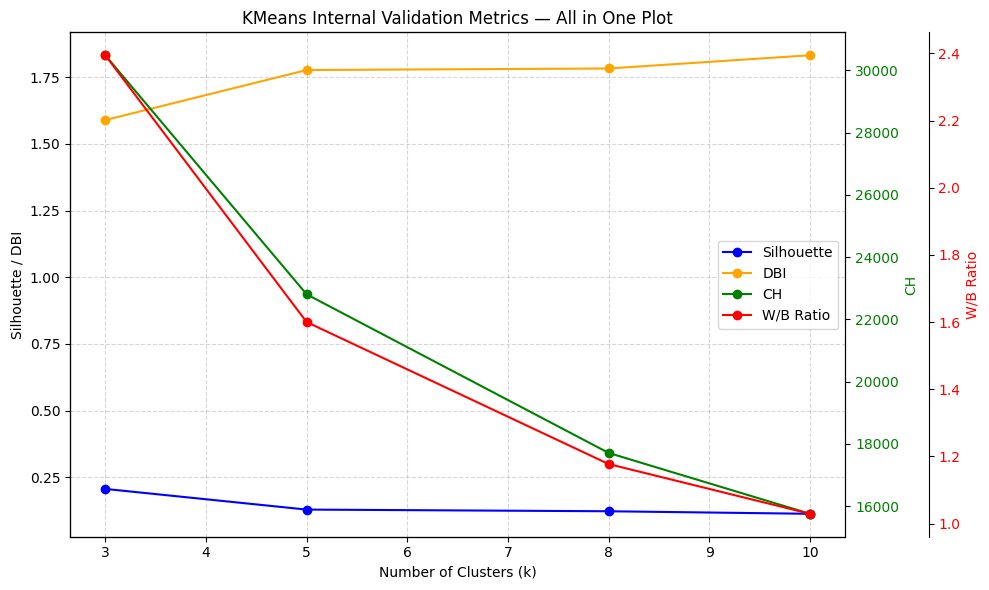

In [110]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load your result ===
df = pd.read_csv("unsupervised_test_robust_scaler_v2/kmeans_metrics.csv")


# === Plot ===
fig, ax1 = plt.subplots(figsize=(10,6))

# Primary axis for Silhouette and DBI
ax1.plot(df['k'], df['silhouette'], marker='o', label='Silhouette', color='blue')
ax1.plot(df['k'], df['dbi'], marker='o', label='DBI', color='orange')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Silhouette / DBI', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle='--', alpha=0.5)

# Secondary axis for CH
ax2 = ax1.twinx()
ax2.plot(df['k'], df['ch'], marker='o', label='CH', color='green')
ax2.set_ylabel('CH', color='green')
ax2.tick_params(axis='y', labelcolor='green')

# Third axis for W/B ratio
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # offset third axis
ax3.plot(df['k'], df['w_over_b'], marker='o', label='W/B Ratio', color='red')
ax3.set_ylabel('W/B Ratio', color='red')
ax3.tick_params(axis='y', labelcolor='red')

# Combine legends from all axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines + lines2 + lines3, labels + labels2 + labels3, loc='best')

plt.title('KMeans Internal Validation Metrics — All in One Plot')
plt.tight_layout()
plt.show()

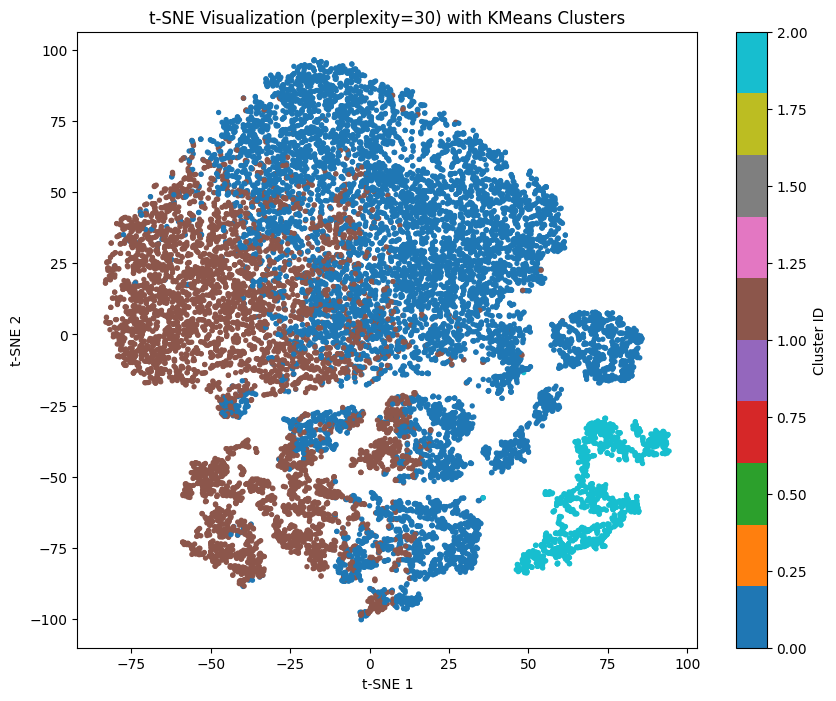

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# =====================
# Load data
# =====================
df = pd.read_csv("unsupervised_modelling_validation_v2.csv")
X = df.select_dtypes(include=[np.number]).fillna(0).values

# Optional scaling (important for PCA & KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#X_scaled = X
# =====================
# Run KMeans (using best k = 5 from earlier)
# =====================
k = 3
km = KMeans(n_clusters=k, n_init=10, random_state=42)
labels_kmeans = km.fit_predict(X_scaled)

# =====================
# Run t-SNE with perplexity=30
# =====================
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_scaled[:20000])  # sample for speed
labels_sample = labels_kmeans[:20000]

# =====================
# Plot t-SNE with cluster colors
# =====================
plt.figure(figsize=(10,8))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels_sample, cmap='tab10', s=8)
plt.title('t-SNE Visualization (perplexity=30) with KMeans Clusters')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

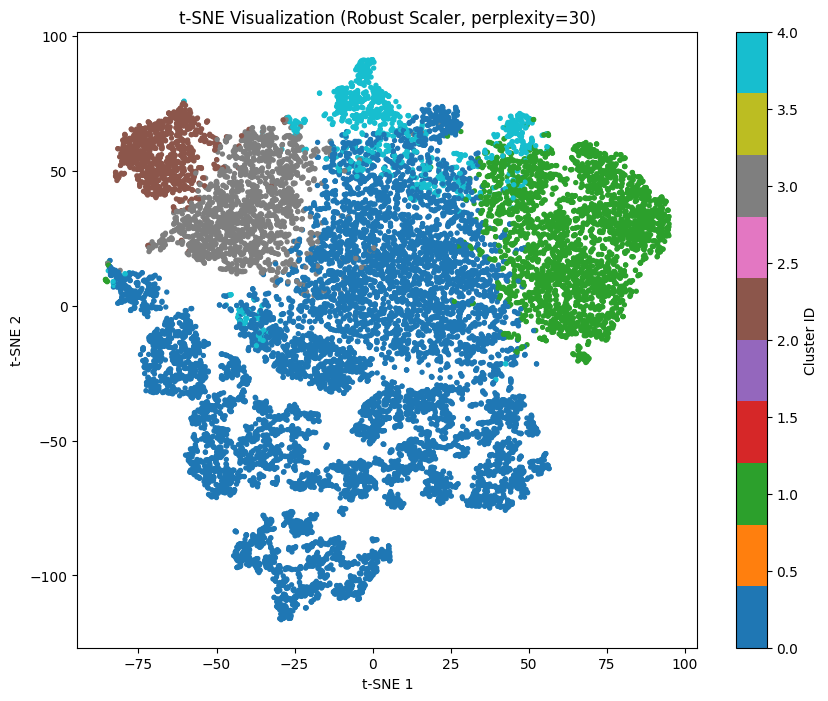

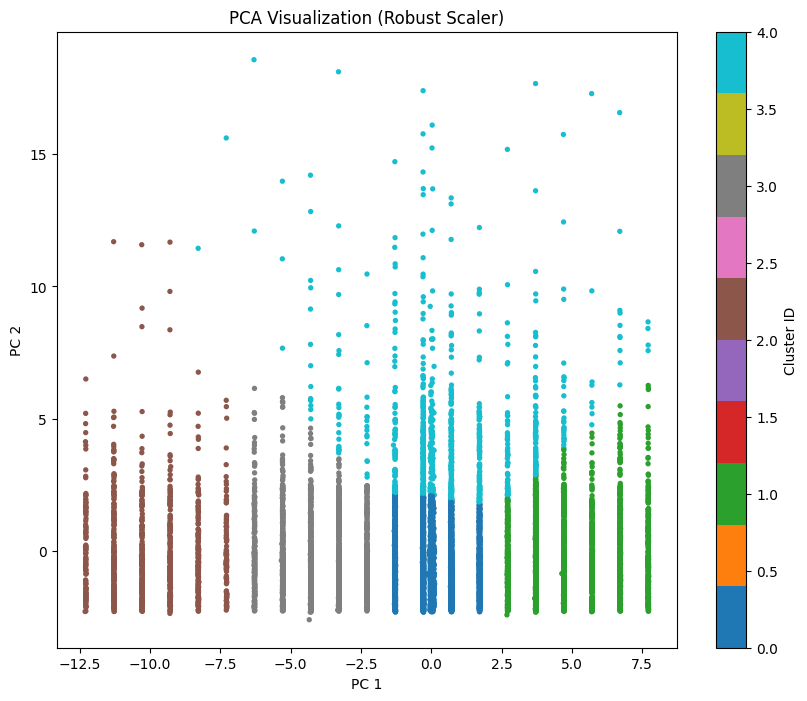

Explained variance ratio: [0.54814172 0.11886811]
Cumulative: [0.54814172 0.66700982]


In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# =====================
# Load data
# =====================
df = pd.read_csv("unsupervised_modelling_validation_v2.csv")
X = df.select_dtypes(include=[np.number]).fillna(0).values

# =====================
# Robust Scaling
# =====================
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# =====================
# KMeans Clustering
# =====================
k = 5
km = KMeans(n_clusters=k, n_init=10, random_state=42)
labels_kmeans = km.fit_predict(X_scaled)

# =====================
# t-SNE with perplexity=30
# =====================
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_scaled[:20000])
labels_sample = labels_kmeans[:20000]

plt.figure(figsize=(10,8))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=labels_sample, cmap='tab10', s=8)
plt.title('t-SNE Visualization (Robust Scaler, perplexity=30)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

# =====================
# PCA visualization
# =====================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled[:20000])

plt.figure(figsize=(10,8))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_sample, cmap='tab10', s=8)
plt.title('PCA Visualization (Robust Scaler)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", pca.explained_variance_ratio_.cumsum())

In [98]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

# Load original data
df = pd.read_csv("unsupervised_modelling_validation_v2.csv")

# Select only numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns
X = df[num_cols].fillna(0).values

# =====================
# Robust Scaling
# =====================
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Create a new DataFrame with scaled numeric columns
df_scaled = df.copy()
df_scaled[num_cols] = X_scaled

# Save the scaled DataFrame
output_path = "unsupervised_modelling_validation_scaled_v2.csv"
df_scaled.to_csv(output_path, index=False)

print(f"Scaled dataset saved to: {output_path}")

Scaled dataset saved to: unsupervised_modelling_validation_scaled_v2.csv


In [85]:
df_scaled['hour'].unique()

array([-0.375,  0.375, -0.875,  0.25 ,  0.875, -0.75 ,  0.   ,  0.5  ,
        0.125, -0.625,  0.75 , -1.125, -0.5  ,  0.625, -1.25 , -0.125,
       -0.25 , -1.5  , -1.   , -1.875, -1.375, -1.75 ,  1.   , -1.625])

In [99]:
df_scaled

,Booking ID,Customer ID,Vehicle Type,hour,temperature_2m_pickup,relative_humidity_2m_pickup,dew_point_2m_pickup,precipitation_pickup,snowfall_pickup,wind_speed_10m_pickup,AvgVTAT_missing_flag,DriverRatings_missing_flag,Avg VTAT_fill,Avg CTAT_fill,Booking Value_fill,Ride Distance_fill,Driver Ratings_fill,Customer Rating_fill
0,"""CNR5884300""","""CID1982111""",eBike,-0.375,0.593750,-1.023256,-0.479452,0.0,0.0,1.400000,1.0,1.0,0.008520,0.000000,-0.017436,0.028281,-0.070063,0.000815
1,"""CNR1326809""","""CID4604802""",Go Sedan,0.375,-0.729167,-0.395349,-0.500000,0.0,0.0,-0.150000,0.0,1.0,-0.656264,-1.917509,-1.348716,-1.430957,0.002733,0.015196
2,"""CNR8494506""","""CID9202816""",Auto,-0.875,0.489583,0.162791,0.678082,0.2,0.0,-0.100000,0.0,0.0,0.917810,-0.423838,0.601284,-0.836260,6.680530,1.652581
3,"""CNR8906825""","""CID2610914""",Premier Sedan,0.250,-0.135417,0.651163,0.561644,0.0,0.0,-0.700000,0.0,0.0,0.862255,-0.082066,-0.453716,0.712224,3.680530,1.985914
4,"""CNR1950162""","""CID9933542""",Bike,0.875,-0.156250,0.581395,0.513699,0.0,0.0,0.450000,0.0,0.0,-0.582190,-1.208649,1.151284,1.787224,-1.319470,-0.347419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145977,"""CNR9572383""","""CID2952237""",Go Mini,0.125,0.479167,-0.279070,0.349315,0.0,0.0,1.900000,0.0,0.0,-0.045153,0.183757,-0.593716,-1.068836,0.680530,1.652581
145978,"""CNR6500631""","""CID4337371""",Go Mini,0.500,-0.427083,0.581395,0.335616,0.0,0.0,-0.483333,0.0,0.0,0.325217,1.930592,-0.158716,1.171315,-5.319470,-1.014086
145979,"""CNR2468611""","""CID2325623""",Go Mini,0.000,-0.052083,0.046512,0.267123,0.0,0.0,0.716667,0.0,0.0,-0.619227,0.209073,2.931284,-0.250654,5.680530,1.985914
145980,"""CNR6358306""","""CID9925486""",Go Sedan,-0.625,-0.010417,0.093023,0.321918,0.0,0.0,1.116667,0.0,0.0,-1.063671,-0.727636,1.726284,-0.658230,-3.319470,-0.014086
